In [247]:
#GENERAL WORKFLOW

#1. Import, etc. 
#2: Read in and clean texts (Iliad, Odyssey, Aeneid)
#3: Run STANZA on each text (acknowledge limits)
#4: Cast lemmas to POS for each text
#5: Window data
#6: Use CountVectorizer to create dataframe
#7: Train logistic regression model (Pandas) to identify Iliad vs Odyssey
#8: Run model on POS-version of Aeneid
#9: Analyze data

In [140]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import re
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt



In [98]:
#STANZA TAGGING
import stanza

#download 
stanza.download('la')  # Latin
stanza.download('grc') # Ancient Greek

#Set up two pipelines for Stanza
nlp_la = stanza.Pipeline('la', processors='tokenize,pos,lemma,depparse')
nlp_grc = stanza.Pipeline('grc', processors='tokenize,pos,lemma,depparse')

2026-05-06 18:44:39 INFO: Downloaded file to /Users/scott/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-06 18:44:39 INFO: Downloading default packages for language: la (Latin) ...
2026-05-06 18:44:40 INFO: File exists: /Users/scott/Library/Caches/stanza/1.11.0/resources/la/default.zip
2026-05-06 18:44:42 INFO: Finished downloading models and saved to /Users/scott/Library/Caches/stanza/1.11.0/resources
2026-05-06 18:44:42 INFO: Downloaded file to /Users/scott/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-06 18:44:42 INFO: Downloading default packages for language: grc (Ancient_Greek) ...
2026-05-06 18:44:43 INFO: File exists: /Users/scott/Library/Caches/stanza/1.11.0/resources/grc/default.zip
2026-05-06 18:44:44 INFO: Finished downloading models and saved to /Users/scott/Library/Caches/stanza/1.11.0/resources
2026-05-06 18:44:44 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with downl

In [100]:
#We need to clean the Aeneid books because they have line numbers and trailing spacing. 
#Aeneid books come from: 
import re

aeneid_books = {}

for i in range(1, 13):
    file_path = f"aeneid/aen{i}.txt"

    clean_lines = []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")

            # remove trailing line numbers
            line = re.sub(r"\s+\d+\s*$", "", line)

            clean_lines.append(line)

    # preserve line structure
    aeneid_books[i] = "\n".join(clean_lines)

In [102]:
#Read in Odyssey and Iliad Books
iliad_books = {}
odyssey_books = {}

for i in range(1, 25):
    iliad_path = f"Iliad/Homer_Iliad_book_{i}.txt"
    odyssey_path = f"Odyssey/Homer_Odyssey_book_{i}.txt"

    with open(iliad_path, "r", encoding="utf-8") as f:
        iliad_books[i] = f.read()

    with open(odyssey_path, "r", encoding="utf-8") as f:
        odyssey_books[i] = f.read()

In [104]:
#RUN STANZA ON AENEID
aeneid_docs = {}

for i in range(1, 13):
    aeneid_docs[i] = nlp_la(aeneid_books[i])

In [106]:
#RUN STANZA ON ILIAD
iliad_docs = {}

for i in range(1, 25):
    iliad_docs[i] = nlp_grc(iliad_books[i])


In [108]:
#RUN STANZA ON ODYSSEY
odyssey_docs = {}

for i in range(1, 25):
    odyssey_docs[i] = nlp_grc(odyssey_books[i])

In [191]:
# POS extraction and window helper functions

def doc_to_pos_lines(doc, use_xpos=False):
    """
    Convert a Stanza doc into a list where each item is the POS-tag sequence
    for one Stanza sentence.

    use_xpos=False -> use UPOS
    use_xpos=True  -> use XPOS when available
    """
    pos_lines = []

    for sent in doc.sentences:
        tags = []
        for word in sent.words:
            tag = word.xpos if use_xpos and word.xpos else word.upos
            if tag is not None:
                tags.append(tag)
        if tags:
            pos_lines.append(" ".join(tags))

    return pos_lines


def make_windows_from_lines(lines, window_size=10, stride=10):
    
    #Turn a list of line-level POS strings into windowed samples.
    
    rows = []

    for start in range(0, len(lines) - window_size + 1, stride):
        chunk = lines[start:start + window_size]
        rows.append({
            "start_line": start + 1,
            "end_line": start + window_size,
            "text": " ".join(chunk)
        })

    return rows

def docs_to_pos_window_df(docs_dict, work_label, window_size=10, stride=10, use_xpos=False):
    
    #Build a dataframe of POS-window texts from a dictionary of Stanza docs.
    
    all_rows = []

    for book_num, doc in docs_dict.items():
        pos_lines = doc_to_pos_lines(doc, use_xpos=use_xpos)
        windows = make_windows_from_lines(pos_lines, window_size=window_size, stride=stride)

        for w in windows:
            w["work"] = work_label
            w["book"] = book_num
            all_rows.append(w)

    return pd.DataFrame(all_rows)


In [192]:
# Build Iliad/Odyssey training data

use_xpos = False

iliad_df = docs_to_pos_window_df(
    iliad_docs,
    "Iliad",
    window_size=10,
    stride=10,
    use_xpos=use_xpos
)

odyssey_df = docs_to_pos_window_df(
    odyssey_docs,
    "Odyssey",
    window_size=10,
    stride=10,
    use_xpos=use_xpos
)

train_df = pd.concat([iliad_df, odyssey_df], ignore_index=True)

# Iliad = 0, Odyssey = 1
train_df["y"] = (train_df["work"] == "Odyssey").astype(int)

# Split by whole book, not random windows
train_df["group"] = train_df["work"] + "_book_" + train_df["book"].astype(str)

train_df.head()


,start_line,end_line,text,work,book,y,group
0,1,10,NOUN VERB NOUN NOUN NOUN NOUN PUNCT PRON ADJ N...,Iliad,1,0,Iliad_book_1
1,11,20,ADV VERB PUNCT VERB PART DET NOUN CCONJ VERB N...,Iliad,1,0,Iliad_book_1
2,21,30,VERB PART NOUN PUNCT SCONJ PART VERB VERB PUNC...,Iliad,1,0,Iliad_book_1
3,31,40,SCONJ PART PART PART NOUN PART CCONJ ADJ VERB ...,Iliad,1,0,Iliad_book_1
4,41,50,NOUN PART ADJ NOUN ADJ VERB PUNCT NOUN PART PR...,Iliad,1,0,Iliad_book_1


In [193]:
# Train/test split by book

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(
    gss.split(train_df["text"], train_df["y"], groups=train_df["group"])
)

train_split = train_df.iloc[train_idx].reset_index(drop=True)
test_split = train_df.iloc[test_idx].reset_index(drop=True)

X_train = train_split["text"]
y_train = train_split["y"]

X_test = test_split["text"]
y_test = test_split["y"]

print("Training windows:")
print(train_split["work"].value_counts())
print()
print("Test windows:")
print(test_split["work"].value_counts())


Training windows:
work
Iliad      573
Odyssey    413
Name: count, dtype: int64

Test windows:
work
Odyssey    169
Iliad      163
Name: count, dtype: int64


In [194]:
model = Pipeline([
    ("counts", CountVectorizer(
        lowercase=False,
        ngram_range=(1, 3),
        token_pattern=r"(?u)\b\w+\b",
        min_df=5,
    )),
    ("scale", StandardScaler(with_mean=False)),
    ("logit", LogisticRegressionCV(
        cv=4,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.3,0.5,0.7],
        Cs=5,
        max_iter=15000,
        random_state=42,
        scoring="accuracy",
        refit=True,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)


,steps,"[('counts', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,False
,preprocessor,None
,tokenizer,None


In [195]:
# Evaluate on remaining Iliad/Odyssey data

test_pred = model.predict(X_test)
test_probs = model.predict_proba(X_test)

print("Best C:", model.named_steps["logit"].C_)
print("Best l1_ratio:", model.named_steps["logit"].l1_ratio_)
print("Accuracy:", accuracy_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, target_names=["Iliad", "Odyssey"]))


Best C: [0.01]
Best l1_ratio: [0.3]
Accuracy: 0.8644578313253012

              precision    recall  f1-score   support

       Iliad       0.80      0.98      0.88       163
     Odyssey       0.97      0.76      0.85       169

    accuracy                           0.86       332
   macro avg       0.88      0.87      0.86       332
weighted avg       0.88      0.86      0.86       332



In [196]:
#inspect test probabilities
test_results = test_split[["work", "book", "start_line", "end_line"]].copy()
test_results["iliad_prob"] = test_probs[:, 0]
test_results["odyssey_prob"] = test_probs[:, 1]
test_results["predicted_side"] = np.where(
    test_results["odyssey_prob"] >= 0.5,
    "Odyssey-like",
    "Iliad-like"
)

test_results.head(20)


,work,book,start_line,end_line,iliad_prob,odyssey_prob,predicted_side
0,Iliad,5,1,10,0.813453,0.186547,Iliad-like
1,Iliad,5,11,20,0.943163,0.056837,Iliad-like
2,Iliad,5,21,30,0.866650,0.133350,Iliad-like
3,Iliad,5,31,40,0.919195,0.080805,Iliad-like
4,Iliad,5,41,50,0.886355,0.113645,Iliad-like
5,Iliad,5,51,60,0.627555,0.372445,Iliad-like
6,Iliad,5,61,70,0.868601,0.131399,Iliad-like
7,Iliad,5,71,80,0.846520,0.153480,Iliad-like
8,Iliad,5,81,90,0.764787,0.235213,Iliad-like
9,Iliad,5,91,100,0.925478,0.074522,Iliad-like


In [197]:
# Predict Aeneid windows

aeneid_df = docs_to_pos_window_df(
    aeneid_docs,
    "Aeneid",
    window_size=10,
    stride=10,
    use_xpos=use_xpos
)

aeneid_probs = model.predict_proba(aeneid_df["text"])

aeneid_df["iliad_prob"] = aeneid_probs[:, 0]
aeneid_df["odyssey_prob"] = aeneid_probs[:, 1]

aeneid_df["predicted_side"] = np.where(
    aeneid_df["odyssey_prob"] >= 0.5,
    "Odyssey-like",
    "Iliad-like"
)

aeneid_df[["book", "start_line", "end_line", "iliad_prob", "odyssey_prob", "predicted_side"]].head(20)


,book,start_line,end_line,iliad_prob,odyssey_prob,predicted_side
0,1,1,10,0.005260,0.994740,Odyssey-like
1,1,11,20,0.245579,0.754421,Odyssey-like
2,1,21,30,0.218500,0.781500,Odyssey-like
3,1,31,40,0.117827,0.882173,Odyssey-like
4,1,41,50,0.598703,0.401297,Iliad-like
5,1,51,60,0.077118,0.922882,Odyssey-like
6,1,61,70,0.038596,0.961404,Odyssey-like
7,1,71,80,0.071323,0.928677,Odyssey-like
8,1,81,90,0.645875,0.354125,Iliad-like
9,1,91,100,0.361052,0.638948,Odyssey-like


In [198]:
# Summary by Aeneid book

book_summary = (
    aeneid_df
    .groupby("book")[["iliad_prob", "odyssey_prob"]]
    .mean()
    .assign(predicted_side=lambda d: np.where(
        d["odyssey_prob"] >= 0.5,
        "Odyssey-like",
        "Iliad-like"
    ))
)

book_summary


,iliad_prob,odyssey_prob,predicted_side
book,,,
1,0.151105,0.848895,Odyssey-like
2,0.360125,0.639875,Odyssey-like
3,0.349888,0.650112,Odyssey-like
4,0.258579,0.741421,Odyssey-like
5,0.350583,0.649417,Odyssey-like
6,0.259433,0.740567,Odyssey-like
7,0.404889,0.595111,Odyssey-like
8,0.350495,0.649505,Odyssey-like
9,0.273833,0.726167,Odyssey-like


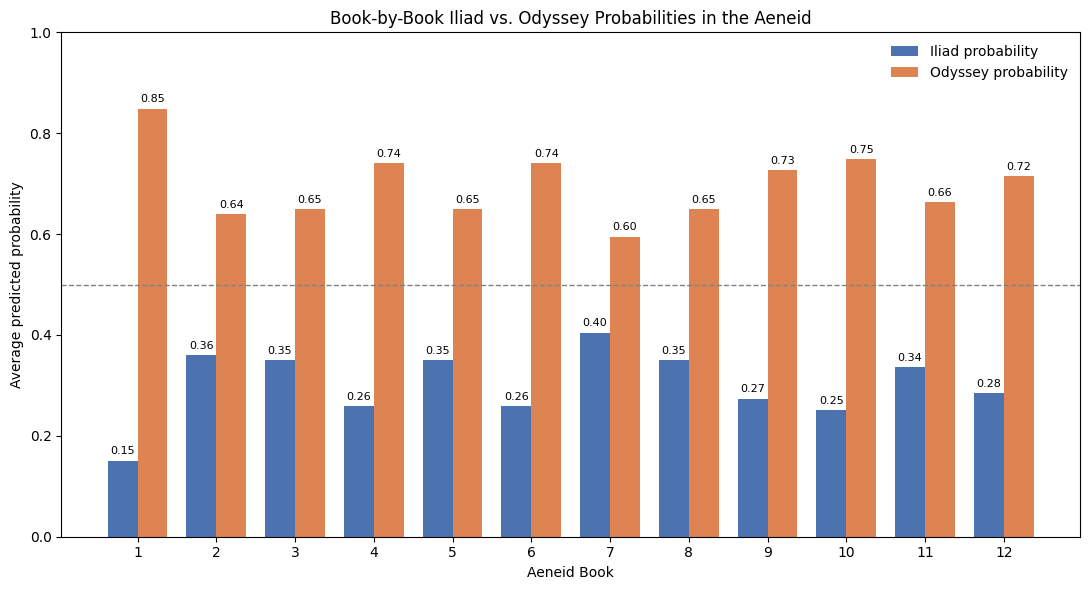

In [215]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = book_summary.reset_index()
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, plot_df["iliad_prob"], width,
               color="#4C72B0", label="Iliad probability")
bars2 = ax.bar(x + width/2, plot_df["odyssey_prob"], width,
               color="#DD8452", label="Odyssey probability")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["book"])
ax.set_ylim(0, 1)
ax.set_xlabel("Aeneid Book")
ax.set_ylabel("Average predicted probability")
ax.set_title("Book-by-Book Iliad vs. Odyssey Probabilities in the Aeneid")
ax.legend(frameon=False)

ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()


In [199]:
# Save window-level predictions
aeneid_df.to_csv("aeneid_pos_ngram_predictions.csv", index=False)


In [200]:
# Inspect the most informative POS n-grams

feature_names = model.named_steps["counts"].get_feature_names_out()
coefs = model.named_steps["logit"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef")

print("Most Iliad-like POS n-grams and their indices:")
print(coef_df.head(20))

print()
print("Most Odyssey-like POS n-grams and their indices:")
print(coef_df.tail(20))


Most Iliad-like POS n-grams and their indices:
              feature      coef
696              PART -0.206660
593    NOUN NOUN NOUN -0.191309
533     NOUN ADJ NOUN -0.157828
586         NOUN NOUN -0.139834
1172        VERB NOUN -0.109694
1179   VERB NOUN NOUN -0.104951
526          NOUN ADJ -0.097304
525              NOUN -0.093832
1230  VERB SCONJ PART -0.055217
599    NOUN NOUN VERB -0.055186
1             ADJ ADJ -0.054860
822    PART VERB NOUN -0.054110
628    NOUN PRON PART -0.042951
1173    VERB NOUN ADJ -0.037509
56       ADJ NOUN ADJ -0.033179
656     NOUN VERB ADJ -0.028054
1124     VERB ADJ ADJ -0.023416
107         ADJ SCONJ -0.022280
754         PART NOUN -0.019156
527      NOUN ADJ ADJ -0.016405

Most Odyssey-like POS n-grams and their indices:
               feature      coef
491      DET PART PART  0.037700
917    PRON PUNCT NOUN  0.039208
941      PUNCT ADJ ADJ  0.046252
1029       PUNCT SCONJ  0.054228
494      DET PART VERB  0.057642
993         PUNCT NOUN  0.068115


In [201]:
# Inspect the most informative POS n-grams, including total occurrences

feature_names = model.named_steps["counts"].get_feature_names_out()
coefs = model.named_steps["logit"].coef_[0]

X_counts = model.named_steps["counts"].transform(train_df["text"])
occurrences = np.asarray(X_counts.sum(axis=0)).ravel()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "occurrences": occurrences
}).sort_values("coef")

print("Most Iliad-like POS n-grams:")
print(coef_df.head(20))

print()
print("Most Odyssey-like POS n-grams:")
print(coef_df.tail(20))


Most Iliad-like POS n-grams:
              feature      coef  occurrences
696              PART -0.206660        27690
593    NOUN NOUN NOUN -0.191309         1242
533     NOUN ADJ NOUN -0.157828         1962
586         NOUN NOUN -0.139834         7717
1172        VERB NOUN -0.109694         8800
1179   VERB NOUN NOUN -0.104951         1647
526          NOUN ADJ -0.097304         7893
525              NOUN -0.093832        49008
1230  VERB SCONJ PART -0.055217          110
599    NOUN NOUN VERB -0.055186         1926
1             ADJ ADJ -0.054860         2351
822    PART VERB NOUN -0.054110         1522
628    NOUN PRON PART -0.042951          128
1173    VERB NOUN ADJ -0.037509         1921
56       ADJ NOUN ADJ -0.033179          929
656     NOUN VERB ADJ -0.028054         1690
1124     VERB ADJ ADJ -0.023416          420
107         ADJ SCONJ -0.022280           88
754         PART NOUN -0.019156         6155
527      NOUN ADJ ADJ -0.016405          668

Most Odyssey-like POS n-g

In [202]:
#Retreive probabilities
aeneid_probs = model.predict_proba(aeneid_df["text"])

aeneid_df["iliad_prob"] = aeneid_probs[:, 0]
aeneid_df["odyssey_prob"] = aeneid_probs[:, 1]

aeneid_df["predicted_side"] = np.where(
    aeneid_df["odyssey_prob"] >= 0.5,
    "Odyssey-like",
    "Iliad-like"
)


In [203]:
#Find low and high confidence examples
aeneid_df["confidence"] = aeneid_df[["iliad_prob", "odyssey_prob"]].max(axis=1)

low_conf_example = aeneid_df.sort_values("confidence", ascending=True).iloc[0]
high_conf_example = aeneid_df.sort_values("confidence", ascending=False).iloc[0]

print("LOW-CONFIDENCE EXAMPLE")
print(low_conf_example[["book", "start_line", "end_line", "iliad_prob", "odyssey_prob", "predicted_side"]])

print()
print("HIGH-CONFIDENCE EXAMPLE")
print(high_conf_example[["book", "start_line", "end_line", "iliad_prob", "odyssey_prob", "predicted_side"]])


LOW-CONFIDENCE EXAMPLE
book                        12
start_line                 251
end_line                   260
iliad_prob             0.49984
odyssey_prob           0.50016
predicted_side    Odyssey-like
Name: 429, dtype: object

HIGH-CONFIDENCE EXAMPLE
book                         1
start_line                 281
end_line                   290
iliad_prob            0.000489
odyssey_prob          0.999511
predicted_side    Odyssey-like
Name: 28, dtype: object


In [204]:
#Let's take a closer look at these two instances.

def plot_feature_contributions(model, text, top_n=15, title=None):
    counts = model.named_steps["counts"]
    scaler = model.named_steps["scale"]
    logit = model.named_steps["logit"]

    feature_names = counts.get_feature_names_out()

    # Transform this one passage the same way the model saw it
    x_counts = counts.transform([text])
    x_scaled = scaler.transform(x_counts)

    # Contribution of each feature to the log-odds
    contributions = x_scaled.toarray()[0] * logit.coef_[0]

    contrib_df = pd.DataFrame({
        "feature": feature_names,
        "contribution": contributions
    })

    # Keep only features actually present in this passage
    contrib_df = contrib_df[contrib_df["contribution"] != 0].copy()

    # Pick strongest absolute contributions
    contrib_df["abs_contribution"] = contrib_df["contribution"].abs()
    contrib_df = contrib_df.sort_values("abs_contribution", ascending=False).head(top_n)

    # Sort for plotting
    contrib_df = contrib_df.sort_values("contribution")

    colors = ["steelblue" if x < 0 else "darkorange" for x in contrib_df["contribution"]]

    plt.figure(figsize=(10, 6))
    plt.barh(contrib_df["feature"], contrib_df["contribution"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("Contribution to log-odds")
    plt.ylabel("POS n-gram feature")
    plt.title(title if title else "Feature contributions")
    plt.tight_layout()
    plt.show()

    return contrib_df


In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_contributions_acl(model, text, top_n=10, title=None, figsize=(3.3, 4.8)):
    counts = model.named_steps["counts"]
    scaler = model.named_steps["scale"]
    logit = model.named_steps["logit"]

    feature_names = counts.get_feature_names_out()
    x_counts = counts.transform([text])
    x_scaled = scaler.transform(x_counts)

    contributions = x_scaled.toarray()[0] * logit.coef_[0]

    contrib_df = pd.DataFrame({
        "feature": feature_names,
        "contribution": contributions
    })

    contrib_df = contrib_df[contrib_df["contribution"] != 0].copy()
    contrib_df["abs_contribution"] = contrib_df["contribution"].abs()
    contrib_df = contrib_df.sort_values("abs_contribution", ascending=False).head(top_n)
    contrib_df = contrib_df.sort_values("contribution")

    colors = ["#4C72B0" if x < 0 else "#DD8452" for x in contrib_df["contribution"]]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(contrib_df["feature"], contrib_df["contribution"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)

    ax.set_xlabel("Contribution to log-odds", fontsize=10)
    ax.set_ylabel("POS n-gram", fontsize=10)
    if title:
        ax.set_title(title, fontsize=10)

    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    return contrib_df


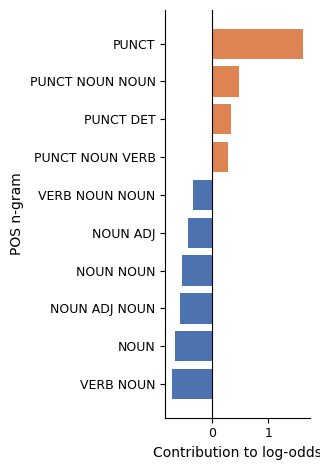

,feature,contribution,abs_contribution
1172,VERB NOUN,-0.712311,0.712311
525,NOUN,-0.654353,0.654353
533,NOUN ADJ NOUN,-0.573772,0.573772
586,NOUN NOUN,-0.532074,0.532074
526,NOUN ADJ,-0.424942,0.424942
1179,VERB NOUN NOUN,-0.340694,0.340694
1004,PUNCT NOUN VERB,0.284904,0.284904
981,PUNCT DET,0.331935,0.331935
999,PUNCT NOUN NOUN,0.480201,0.480201
939,PUNCT,1.627042,1.627042


In [224]:
#Low confidence
plot_feature_contributions_acl(
    model,
    low_conf_example["text"],
    top_n=10,
    title=None
)


In [219]:
# Average number of PUNCT tags per 10-line Aeneid window
aeneid_df["punct_count"] = aeneid_df["text"].str.count(r"\bPUNCT\b")
avg_punct = aeneid_df["punct_count"].mean()

print("Average PUNCT per 10-line Aeneid window:", avg_punct)


Average PUNCT per 10-line Aeneid window: 23.14798206278027


In [220]:
#Compare each example's punctuation count to the Aeneid average
aeneid_df["punct_count"] = aeneid_df["text"].str.count(r"\bPUNCT\b")
avg_punct = aeneid_df["punct_count"].mean()

low_punct = low_conf_example["text"].count("PUNCT")
high_punct = high_conf_example["text"].count("PUNCT")

print("Average PUNCT per 10-line Aeneid window:", round(avg_punct, 2))
print()

print("LOW-CONFIDENCE EXAMPLE")
print("PUNCT count:", low_punct)
print("Difference from average:", round(low_punct - avg_punct, 2))
print()

print("HIGH-CONFIDENCE EXAMPLE")
print("PUNCT count:", high_punct)
print("Difference from average:", round(high_punct - avg_punct, 2))


Average PUNCT per 10-line Aeneid window: 23.15

LOW-CONFIDENCE EXAMPLE
PUNCT count: 26
Difference from average: 2.85

HIGH-CONFIDENCE EXAMPLE
PUNCT count: 32
Difference from average: 8.85


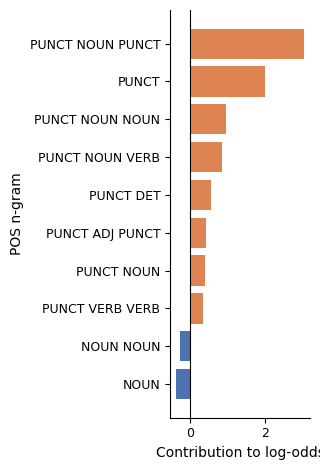

,feature,contribution,abs_contribution
525,NOUN,-0.375163,0.375163
586,NOUN NOUN,-0.286501,0.286501
1050,PUNCT VERB VERB,0.346845,0.346845
993,PUNCT NOUN,0.394540,0.394540
949,PUNCT ADJ PUNCT,0.419084,0.419084
981,PUNCT DET,0.553225,0.553225
1004,PUNCT NOUN VERB,0.854712,0.854712
999,PUNCT NOUN NOUN,0.960403,0.960403
939,PUNCT,2.002514,2.002514
1002,PUNCT NOUN PUNCT,3.046066,3.046066


In [226]:
plot_feature_contributions_acl(
    model,
    high_conf_example["text"],
    top_n=10,
    title=None
)


In [227]:
most_iliadic = aeneid_df.sort_values("iliad_prob", ascending=False).iloc[0]

print("MOST ILIADIC PASSAGE")
print(most_iliadic[[
    "book", "start_line", "end_line",
    "iliad_prob", "odyssey_prob", "predicted_side"
]])


MOST ILIADIC PASSAGE
book                       7
start_line               311
end_line                 320
iliad_prob          0.923119
odyssey_prob        0.076881
predicted_side    Iliad-like
Name: 253, dtype: object


In [228]:
#Seems like Punctuation is a super common feature, but punctuation wouldn't have existed in Oral storytelling. 
#What happens if we remove punctuation and retrain our model? 

#First, how common is punctuation in each poem?

for name, df in [("Iliad", iliad_df), ("Odyssey", odyssey_df)]:
    punct_count = df["text"].str.count(r"\bPUNCT\b").sum()
    total_tags = df["text"].str.split().str.len().sum()
    print(name, punct_count / total_tags)

Iliad 0.11723003314232124
Odyssey 0.14301056022910327


In [229]:
# Function to rebuild POS lines without punctuation
def doc_to_pos_lines(doc, use_xpos=False):
    pos_lines = []
    for sent in doc.sentences:
        tags = []
        for word in sent.words:
            tag = word.xpos if use_xpos and word.xpos else word.upos
            if tag is not None and tag != "PUNCT":
                tags.append(tag)
        if tags:
            pos_lines.append(" ".join(tags))
    return pos_lines

In [230]:
# Obtain training data without punctuation
use_xpos = False

iliad_df = docs_to_pos_window_df(iliad_docs, "Iliad", use_xpos=use_xpos)
odyssey_df = docs_to_pos_window_df(odyssey_docs, "Odyssey", use_xpos=use_xpos)

train_df = pd.concat([iliad_df, odyssey_df], ignore_index=True)
train_df["y"] = (train_df["work"] == "Odyssey").astype(int)
train_df["group"] = train_df["work"] + "_book_" + train_df["book"].astype(str)


In [231]:
# Re-split train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(
    gss.split(train_df["text"], train_df["y"], groups=train_df["group"])
)

train_split = train_df.iloc[train_idx].reset_index(drop=True)
test_split = train_df.iloc[test_idx].reset_index(drop=True)

X_train = train_split["text"]
y_train = train_split["y"]
X_test = test_split["text"]
y_test = test_split["y"]


In [236]:
model = Pipeline([
    ("counts", CountVectorizer(
        lowercase=False,
        ngram_range=(1, 3),
        token_pattern=r"(?u)\b\w+\b",
        min_df=5,
    )),
    ("scale", StandardScaler(with_mean=False)),
    ("logit", LogisticRegressionCV(
        cv=4,
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.3,0.5,0.7],
        Cs=5,
        max_iter=15000,
        random_state=42,
        scoring="accuracy",
        refit=True,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)


,steps,"[('counts', ...), ('scale', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,False
,preprocessor,None
,tokenizer,None


In [245]:
# Evaluate on remaining Iliad/Odyssey data

test_pred = model.predict(X_test)
test_probs = model.predict_proba(X_test)

print("Best C:", model.named_steps["logit"].C_)
print("Best l1_ratio:", model.named_steps["logit"].l1_ratio_)
print("Accuracy:", accuracy_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, target_names=["Iliad", "Odyssey"]))


Best C: [0.01]
Best l1_ratio: [0.3]
Accuracy: 0.6295180722891566

              precision    recall  f1-score   support

       Iliad       0.58      0.88      0.70       163
     Odyssey       0.77      0.39      0.52       169

    accuracy                           0.63       332
   macro avg       0.67      0.63      0.61       332
weighted avg       0.68      0.63      0.61       332



In [238]:
# Run again on Aeneid
aeneid_df = docs_to_pos_window_df(aeneid_docs, "Aeneid", use_xpos=use_xpos)

aeneid_probs = model.predict_proba(aeneid_df["text"])
aeneid_df["iliad_prob"] = aeneid_probs[:, 0]
aeneid_df["odyssey_prob"] = aeneid_probs[:, 1]
aeneid_df["predicted_side"] = np.where(
    aeneid_df["odyssey_prob"] >= 0.5,
    "Odyssey-like",
    "Iliad-like"
)

aeneid_df[["book", "start_line", "end_line", "iliad_prob", "odyssey_prob", "predicted_side"]].head(20)


,book,start_line,end_line,iliad_prob,odyssey_prob,predicted_side
0,1,1,10,0.563181,0.436819,Iliad-like
1,1,11,20,0.550078,0.449922,Iliad-like
2,1,21,30,0.417955,0.582045,Odyssey-like
3,1,31,40,0.365034,0.634966,Odyssey-like
4,1,41,50,0.477003,0.522997,Odyssey-like
5,1,51,60,0.506034,0.493966,Iliad-like
6,1,61,70,0.220308,0.779692,Odyssey-like
7,1,71,80,0.359269,0.640731,Odyssey-like
8,1,81,90,0.639214,0.360786,Iliad-like
9,1,91,100,0.461470,0.538530,Odyssey-like


In [240]:
#Additional book summary
book_summary = (
    aeneid_df
    .groupby("book")[["iliad_prob", "odyssey_prob"]]
    .mean()
    .reset_index()
)

book_summary["predicted_side"] = np.where(
    book_summary["odyssey_prob"] >= 0.5,
    "Odyssey-like",
    "Iliad-like"
)

book_summary


,book,iliad_prob,odyssey_prob,predicted_side
0,1,0.462247,0.537753,Odyssey-like
1,2,0.416019,0.583981,Odyssey-like
2,3,0.536520,0.463480,Iliad-like
3,4,0.421453,0.578547,Odyssey-like
4,5,0.453140,0.546860,Odyssey-like
5,6,0.434426,0.565574,Odyssey-like
6,7,0.537399,0.462601,Iliad-like
7,8,0.500967,0.499033,Iliad-like
8,9,0.419614,0.580386,Odyssey-like
9,10,0.448568,0.551432,Odyssey-like


In [242]:
# Updated top features
feature_names = model.named_steps["counts"].get_feature_names_out()
coefs = model.named_steps["logit"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs
}).sort_values("coef")

print("Most Iliad-like POS n-grams:")
print(coef_df.head(20))

print()
print("Most Odyssey-like POS n-grams:")
print(coef_df.tail(20))


Most Iliad-like POS n-grams:
              feature      coef
523     NOUN ADJ NOUN -0.114513
582         NOUN NOUN -0.092810
590    NOUN NOUN NOUN -0.069307
515          NOUN ADJ -0.062917
69      ADJ NOUN PART -0.058164
792    PART VERB NOUN -0.057327
864     PRON PART ADP -0.049278
1033    VERB NOUN ADJ -0.049099
675              PART -0.048286
624    NOUN PRON PART -0.039039
734         PART NOUN -0.037714
2         ADJ ADJ ADJ -0.032634
941   SCONJ PART NOUN -0.019974
942   SCONJ PART PART -0.018809
491      INTJ ADJ ADJ -0.018665
956       SCONJ SCONJ -0.017787
1040   VERB NOUN NOUN -0.015574
871    PRON PART PART -0.014758
728      PART DET ADJ -0.014483
751         PART PART -0.012769

Most Odyssey-like POS n-grams:
               feature      coef
1080   VERB SCONJ PRON  0.025169
50      ADJ CCONJ PRON  0.028456
443    CCONJ VERB VERB  0.030995
43           ADJ CCONJ  0.032516
951     SCONJ PRON DET  0.033713
907     SCONJ ADJ PART  0.038407
1036     VERB NOUN AUX  0.041514
930